<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_n_dog_data_preprocessing_ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

In [4]:
train_path = '/content/drive/MyDrive/cat_n_dog/training_set/training_set'
test_path = '/content/drive/MyDrive/cat_n_dog/test_set/test_set'

In [5]:
train_list = []
train_target = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('jpg')):
            if(filename[0] == 'c'):
                train_target.append(0)
            elif(filename[0] == 'd'):
                train_target.append(1)
            train_count = os.path.join(dirname, filename)
            train_list.append(train_count)

In [6]:
test_list = []
test_target = []

for dirname, _, filenames in os.walk(test_path):
    for filename in filenames:
        if(filename.endswith('jpg')):
            if(filename[0] == 'c'):
                test_target.append(0)
            elif(filename[0] == 'd'):
                test_target.append(1)
            test_count = os.path.join(dirname, filename)
            test_list.append(test_count)

In [7]:
# image_preprocessing: center cropping
def crop_center(img):
    y, x, z = img.shape
    crop_size = min(y, x)
    start_x = x // 2 - (crop_size // 2)
    start_y = y // 2 - (crop_size // 2)
    return img[start_y:start_y + crop_size, start_x:start_x + crop_size]

reference: https://stackoverflow.com/questions/39382412/crop-center-portion-of-a-numpy-image

In [8]:
# image_preprocessing: Normalization
def minmax_scaler(img):
    return img / 255.0

(375, 499, 3)
(375, 375, 3)
[0.41568627 0.38823529 0.35686275] [0.41568627 0.38823529 0.35686275] [0.42352941 0.4        0.35294118] [0.40784314 0.38431373 0.3372549 ] [0.42352941 0.4        0.35294118] [0.55686275 0.53333333 0.48627451] [0.52156863 0.49411765 0.45490196] [0.56470588 0.5372549  0.49803922] [0.53333333 0.50588235 0.46666667] [0.53333333 0.50588235 0.4745098 ] 
[0.41568627 0.38823529 0.35686275] [0.41568627 0.38823529 0.35686275] [0.42352941 0.4        0.35294118] [0.40392157 0.38039216 0.33333333] [0.42352941 0.4        0.35294118] [0.55686275 0.53333333 0.48627451] [0.52156863 0.49411765 0.45490196] [0.56862745 0.54117647 0.50196078] [0.53333333 0.50588235 0.46666667] [0.53333333 0.50588235 0.4745098 ] 
[0.41568627 0.38823529 0.35686275] [0.41568627 0.38823529 0.35686275] [0.42352941 0.4        0.35294118] [0.40392157 0.38039216 0.33333333] [0.42352941 0.4        0.35294118] [0.55686275 0.53333333 0.48627451] [0.5254902  0.49803922 0.45882353] [0.56862745 0.54117647 0.

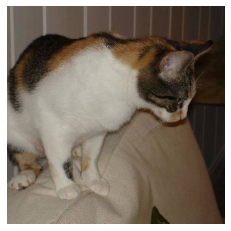

In [9]:
# function test
from tensorflow.keras.preprocessing import image
img = image.load_img(train_list[0])
img_np = np.array(img)
print(img_np.shape)
img_crop = crop_center(img_np)
img_scaled = minmax_scaler(img_crop)
print(img_scaled.shape)
for i in range(0, 10):
    for j in range(0, 10):
        print(img_scaled[i][j], end = ' ')
    print()
for i in range(0, 10):
    for j in range(0, 10):
        print(img_crop[i][j], end = ' ')
    print()
plt.imshow(img_scaled)
plt.axis('off')
plt.show()

In [10]:
train_set = []

for i, f in enumerate(train_list):
    img = image.load_img(f)
    img_np = np.array(img)
    train_set.append(img)

In [12]:
for i, img in enumerate(train_set):
    img_np = np.array(img)
    train_set[i] = img_np

In [13]:
for img in train_set:
    img_crop = crop_center(img)
    img_scaled = minmax_scaler(img_crop)
    train_set[i] = img_scaled

In [14]:
test_set = []

for i, f in enumerate(test_list):
    img = image.load_img(f)
    img_np = np.array(img)
    test_set.append(img_np)

In [15]:
for img in test_set:
    img_crop = crop_center(img)
    img_scaled = minmax_scaler(img_crop)
    test_set[i] = img_scaled

In [16]:
train_set_np = np.array(train_set)
test_set_np = np.array(test_set)
train_target_np = np.array(train_target)
test_target_np = np.array(test_target)

np.save('/content/drive/MyDrive/cat_n_dog/data_numpy/train_set', train_set_np)
np.save('/content/drive/MyDrive/cat_n_dog/data_numpy/test_set', test_set_np)
np.save('/content/drive/MyDrive/cat_n_dog/data_numpy/train_target', train_target_np)
np.save('/content/drive/MyDrive/cat_n_dog/data_numpy/test_target', test_target_np)

<ipython-input-16-e5e7ca2f0a9d>:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  train_set_np = np.array(train_set)
<ipython-input-16-e5e7ca2f0a9d>:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  test_set_np = np.array(test_set)
